# Friday News Dump — the quant teardown 🗑️📉

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Friday_night_dump%3F: Mixed](https://img.shields.io/badge/Friday_night_dump%3F-Mixed-8b949e?style=flat-square)

**Claim (DellaVigna-Pollet 2009, transposed to unambiguous bad news).** Negative corporate disclosures filed on Friday — especially after the close — receive attention-limited underreaction and exhibit stronger negative post-event drift than identical weekday disclosures.

**Design.** Stratified panel of negative 8-Ks (Item 4.02 non-reliance, Item 2.06 impairments, Item 5.02 CEO resignations) from the EDGAR full-text search API, 2004-08-23 → 2026-06-30, acceptance timestamps to the second; Item 2.02 earnings 8-Ks as the timing control. Market-adjusted CARs vs SPY; Welch *t* on the Friday-vs-Mon-Thu drift gap; label-permutation placebo; penny-stock screen at $1. ONE execution convention: day 0 = first session whose close reflects the filing.

> 💡 **In plain words:** we check whether the market really sleeps through Friday-night bad news (it doesn't), and separately whether companies really try the trick (they do — but after hours, not specifically on Friday).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from friday_news_dump import data, strategy as st

AS_OF = "2026-06-30"
HAVE_REAL = data.have_real()
print("real cache present:", HAVE_REAL,
      "(offline CI runs quote the frozen numbers in R — mirror of docs/results.md)")

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_filings': 3818, 'n_bad': 3122, 'n_ctrl': 696, 'n_by_class': {'ceo_exit': 1051, 'nonreliance': 1044, 'impairment': 1027}, 'n_mapped': 1234, 'n_car': 1027, 'first': '2004-08-27', 'last': '2026-06-15', 'fp_events': 'e566cab9c587', 'fp_spy': 'c9b5637c9a7f', 'n_sessions': 5658, 'main': {'n_fri': 210, 'n_oth': 817, 'ar0_fri': 65.4, 'ar0_oth': -70.4, 'ar0_t_fri': 0.83, 'ar0_t_oth': -1.79, 'ar0_gap_t': 1.54, 'drift_fri': -45.6, 'drift_oth': -56.3, 'drift_t_fri': -0.4, 'drift_t_oth': -1.06, 'gap': 10.7, 'gap_t': 0.08, 'gap_t_wins': 0.02, 'p_perm': 0.523, 'pooled': -54.1, 'pooled_t': -1.12, 'pooled_t_wins': -1.45, 'car010_gap_t': 1.07, 'pm_n': 130, 'pm_drift': -2.2, 'pm_drift_t': -0.02, 'pm_gap': 59.5, 'pm_gap_t': 0.39}, 'robust': [('nonreliance', 254, 61, 247.6, 0.82, -6.9, -0.05), ('impairment', 526, 91, 109.0, 0.88, -48.7, -1.26), ('ceo_exit', 247, 58, -400.6, -1.39, -114.2, -0.88), ('2004-2015', 344, 62, -63.7, -0.41, -11.2, -0.17), ('2016-2026', 683, 148, 48.0, 0.28, -75.8, -1.17)], 'shares': {'friday': (21.3, 7.9, 10.67), 'after_close': (57.9, 47.6, 4.94), 'friday_pm': (12.8, 1.4, 15.15), 'wd_bad': [19.7, 19.6, 19.4, 20.0, 21.3], 'wd_ctrl': [12.6, 22.7, 29.0, 27.7, 7.9], 'friday_null': 20.3, 'friday_vs_null_z': 1.4}, 'trades': [('Friday filers, borrow 5%/yr', 210, 9.6, 45.6, 0.4, 0.56, 41.8, 3.8, 0.03), ('Friday filers, borrow 2%/yr', 210, 9.6, 45.6, 0.4, 0.56, 29.9, 15.7, 0.14), ('Friday-PM only, borrow 5%/yr', 130, 6.0, 2.2, 0.02, 0.6, 41.8, -39.6, -0.28), ('Friday-PM only, borrow 2%/yr', 130, 6.0, 2.2, 0.02, 0.6, 29.9, -27.7, -0.19)], 'path_fri': [65.4, 28.1, 45.2, 17.0, 64.9, 111.0, 80.7, 57.7, 42.5, 23.8, 19.8], 'path_oth': [-70.4, -106.1, -100.7, -136.1, -109.1, -133.7, -126.7, -145.5, -132.9, -137.4, -126.7], 'syn': [('null', 21.5, -26.2, -0.38, 0.34), ('drift -300 bps Fri', 21.5, -326.2, -4.69, 0.0), ('hide p_fri=0.35', 37.1, -22.3, -0.38, 0.364)]}


real cache present: True (offline CI runs quote the frozen numbers in R — mirror of docs/results.md)


## 0 · Data stamp

| Field | Value |
|---|---|
| Filing panel | 3,818 8-Ks — 3,122 negative (ceo_exit 1,051 · nonreliance 1,044 · impairment 1,027) + 696 earnings-control |
| Sampling | first 12 eligible FTS hits per class × quarter (8 control) — documented, weekday-orthogonal cap; pure `8-K` only, item codes verified |
| Return panel | 1,234/3,122 filers map to a live ticker (SEC current map); full −1..+10 window + ≥$1 screen → **1,027 events** (2004-08-27 → 2026-06-15), 210 Friday-filed |
| Fingerprints | events `e566cab9c587` · SPY `c9b5637c9a7f` (5,658 sessions) · as-of 2026-06-30 |
| Survivorship | **SEVERE and named**: 60% of filers are gone from the current ticker map — drift magnitudes are understated; the timing shares (§3) use the full panel and carry no survivorship |

> 💡 The survivorship censoring hits Friday and Mon-Thu filers alike, so the Friday-vs-weekday *gap* — the claim under test — remains a fair contrast on the visible tape; the *level* of drift is the biased quantity.

In [2]:
# live recompute (cache-first; CI without cache quotes R)
if HAVE_REAL:
    panel = data.load_panel(require_prices=True)
    px = data.load_prices(asof=AS_OF)
    kept, armat = st.event_ars(panel, px)
    fri = kept['friday'].to_numpy()
    g = st.group_stats(fri, armat)
    print(f"events {len(kept)} | Friday {g['n_fri']} | gap "
          f"{g['gap_bps']:+.1f} bps Welch t={g['gap_t']:+.2f} | pooled drift "
          f"{g['pooled_drift_bps']:+.1f} bps t={g['pooled_drift_t']:+.2f}")
    assert abs(g['gap_t'] - R['main']['gap_t']) < 0.05, 'drifted from results.md!'
else:
    print('cache absent -> quoting frozen R (mirror of docs/results.md)')


events 1027 | Friday 210 | gap +10.7 bps Welch t=+0.08 | pooled drift -54.1 bps t=-1.12


## 1 · The main test — reaction and drift, Friday vs Mon-Thu

| group | n | AR day 0 | drift CAR[+1..+10] | drift *t* |
|---|--:|--:|--:|--:|
| Friday filers | 210 | +65.4 bps (*t* = +0.83) | -45.6 bps | -0.40 |
| Mon-Thu filers | 817 | -70.4 bps (*t* = -1.79) | -56.3 bps | -1.06 |

**Gap = +10.7 bps, Welch *t* = +0.08** (1%-winsorized *t* = +0.02); permutation placebo **p = 0.523** (2,000 seeded draws). CAR[0..+10] gap Welch *t* = +1.07 — Friday filers end *less* negative. Friday-after-close subset (n = 130): drift -2.2 bps (*t* = -0.02), gap vs rest +59.5 bps (*t* = +0.39).

Pooled drift, all bad news: **-54.1 bps/10d**, *t* = -1.12 (winsorized -1.45) — the sign the literature predicts, below the *t* ≥ 2 bar on this survivor tape.

> 💡 **In plain words:** whatever day the bad news lands, the next ten sessions look the same — a slow, statistically unremarkable bleed of about half a percent. No extra Friday slide.

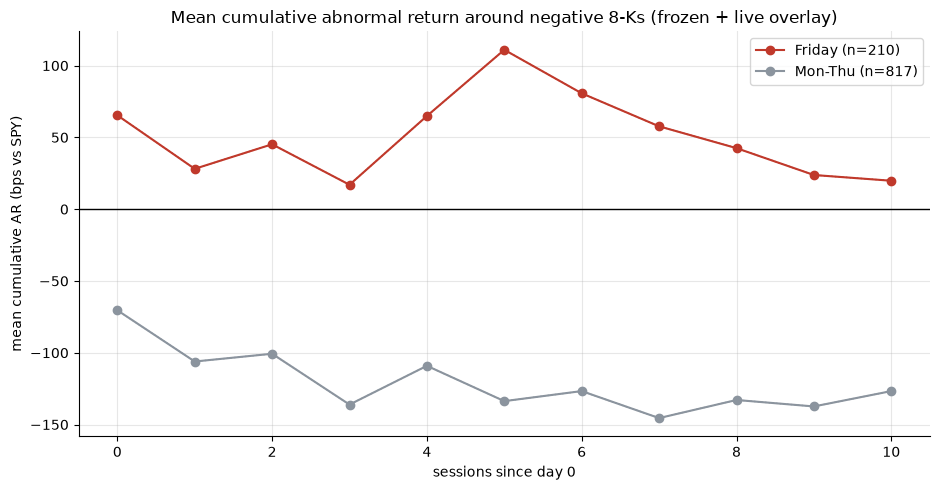

In [3]:
t = np.arange(11)
fig, ax = plt.subplots()
ax.plot(t, R['path_fri'], marker='o', color=RED,
        label=f"Friday (n={R['main']['n_fri']})")
ax.plot(t, R['path_oth'], marker='o', color=GREY,
        label=f"Mon-Thu (n={R['main']['n_oth']})")
if HAVE_REAL:  # redraw live from the cache on top (must overlay exactly)
    pf = (armat[fri].mean(axis=0).cumsum() * 1e4)
    po = (armat[~fri].mean(axis=0).cumsum() * 1e4)
    ax.plot(t, pf, lw=1, ls=':', color=RED)
    ax.plot(t, po, lw=1, ls=':', color=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('sessions since day 0'); ax.set_ylabel('mean cumulative AR (bps vs SPY)')
ax.set_title('Mean cumulative abnormal return around negative 8-Ks (frozen + live overlay)')
ax.legend(); plt.tight_layout(); plt.show()


## 2 · Robustness — six cells, six nothings

| slice | n (Friday) | gap bps | Welch *t* | pooled drift bps (*t*) |
|---|--:|--:|--:|--:|
| nonreliance | 254 (61) | +247.6 | +0.82 | -6.9 (-0.05) |
| impairment | 526 (91) | +109.0 | +0.88 | -48.7 (-1.26) |
| ceo_exit | 247 (58) | -400.6 | -1.39 | -114.2 (-0.88) |
| 2004-2015 | 344 (62) | -63.7 | -0.41 | -11.2 (-0.17) |
| 2016-2026 | 683 (148) | +48.0 | +0.28 | -75.8 (-1.17) |

Signs both ways, every |*t*| < 1.4. The one seemingly-interesting cell (CEO exits, gap −400 bps) is *t* = −1.39 across 58 Friday events and flips sign in the other two classes — exactly what multiple-comparison noise looks like.

> 💡 **In plain words:** slice it by kind of bad news or by decade — no slice shows the Friday effect.

In [4]:
# permutation placebo, live (reduced draws in-notebook; canonical p in R)
if HAVE_REAL:
    p = st.placebo_gap(fri, armat, n_perm=300, seed=608)
    print(f'placebo (300 draws, live) p = {p:.3f}   | canonical (2,000 draws) '
          f"p = {R['main']['p_perm']:.3f}")
else:
    print(f"canonical placebo p = {R['main']['p_perm']:.3f} (2,000 draws, seeded)")


placebo (300 draws, live) p = 0.497   | canonical (2,000 draws) p = 0.523


## 3 · Third axis — the hiding itself (full panel, zero survivorship)

| share | bad news | earnings control | two-prop z |
|---|--:|--:|--:|
| Friday | 21.3% | 7.9% | +10.67 |
| after 16:00 ET | 57.9% | 47.6% | +4.94 |
| Friday after close | 12.8% | 1.4% | +15.15 |

Against the **uniform-calendar null** (Fridays = 20.3% of EDGAR-open days) the bad-news Friday share is z = +1.40 — *not* significant. The weekday mix of bad news is flat (19.7 / 19.6 / 19.4 / 20.0 / 21.3%); the *control* is what deserts Friday (7.9%). The unambiguous hiding margin is the **clock**: after-hours (z = +4.9) and the Friday-PM combination (z = +15.2, a 9× ratio) — consistent with Niessner (2015) and deHaan et al. (2015).

> 💡 **In plain words:** companies genuinely wait for the closing bell to release bad news. They do NOT particularly wait for Friday — Friday just looks dirty because good news avoids it.

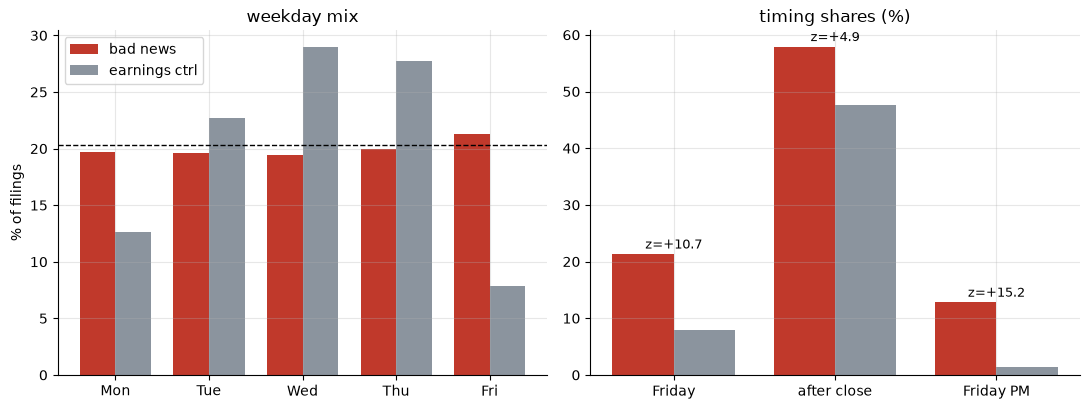

In [5]:
x = np.arange(5); w = 0.38
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.bar(x - w/2, R['shares']['wd_bad'], w, color=RED, label='bad news')
ax1.bar(x + w/2, R['shares']['wd_ctrl'], w, color=GREY, label='earnings ctrl')
ax1.axhline(R['shares']['friday_null'], ls='--', c='k', lw=1)
ax1.set_xticks(x, ['Mon','Tue','Wed','Thu','Fri']); ax1.set_ylabel('% of filings')
ax1.set_title('weekday mix'); ax1.legend()
pairs = [('Friday', 'friday'), ('after close', 'after_close'),
         ('Friday PM', 'friday_pm')]
xb = np.arange(3)
ax2.bar(xb - w/2, [R['shares'][k][0] for _, k in pairs], w, color=RED)
ax2.bar(xb + w/2, [R['shares'][k][1] for _, k in pairs], w, color=GREY)
for i, (_, k) in enumerate(pairs):
    ax2.text(i, R['shares'][k][0] + 1, f"z=+{R['shares'][k][2]:.1f}",
             ha='center', fontsize=9)
ax2.set_xticks(xb, [p for p, _ in pairs]); ax2.set_title('timing shares (%)')
plt.tight_layout(); plt.show()


## 4 · Tradability — the cost stack

Entry at the day-0 close (the ONE lag — the filing is public before that close by construction, so the rule is implementable but never captures the day-0 hit), cover at close(+10), SPY-hedged; 10 bps one-way × 2 stock legs + 1 bp × 2 hedge legs; shorts pay borrow.

| rule | n (~/yr) | gross/event | costs | net/event |
|---|--:|--:|--:|--:|
| Friday filers, borrow 5%/yr | 210 (~10) | +45.6 bps (*t* = +0.40, hit 56%) | 42 bps | **+3.8 bps** (*t* = +0.03) |
| Friday filers, borrow 2%/yr | 210 (~10) | +45.6 bps (*t* = +0.40, hit 56%) | 30 bps | **+15.7 bps** (*t* = +0.14) |
| Friday-PM only, borrow 5%/yr | 130 (~6) | +2.2 bps (*t* = +0.02, hit 60%) | 42 bps | **-39.6 bps** (*t* = -0.28) |
| Friday-PM only, borrow 2%/yr | 130 (~6) | +2.2 bps (*t* = +0.02, hit 60%) | 30 bps | **-27.7 bps** (*t* = -0.19) |

Gross never clears *t* = 0.5; net is a rounding error or negative. Capacity makes it worse: the median 4.02/2.06 filer is a small cap with real HTB risk.

> 💡 **In plain words:** even free of costs there's nothing here; with costs it's a slow bleed of commissions.

## 5 · Synthetic machinery control *(never market evidence)*

Deterministic planted-effect world (seed 608): the harness must stay quiet at the null and light up when a Friday drift or a Friday-hiding propensity is planted.

In [6]:
print(f"{'world':22s} {'fri share':>9s} {'gap bps':>9s} {'Welch t':>8s} {'placebo p':>10s}")
for lab, kw in [('null', {}), ('drift -300 bps Fri', dict(drift_fri=-0.03)),
                ('hide p_fri=0.35', dict(p_fri=0.35))]:
    pl, am = data.synthetic_world(**kw)
    gs = st.group_stats(pl['friday'].to_numpy(), am)
    pp = st.placebo_gap(pl['friday'].to_numpy(), am, n_perm=300, seed=608)
    print(f"{lab:22s} {pl['friday'].mean()*100:8.1f}% {gs['gap_bps']:+9.1f} "
          f"{gs['gap_t']:+8.2f} {pp:10.3f}")
print('\ncanonical (500-draw) rows, mirror of results.md:')
for lab, fs, gb, gt, pp in R['syn']:
    print(f'  {lab:22s} fri {fs:4.1f}%  gap {gb:+7.1f} bps  t {gt:+5.2f}  p {pp:.3f}')


world                  fri share   gap bps  Welch t  placebo p
null                       21.5%     -26.2    -0.38      0.340


drift -300 bps Fri         21.5%    -326.2    -4.69      0.000
hide p_fri=0.35            37.1%     -22.3    -0.38      0.333

canonical (500-draw) rows, mirror of results.md:
  null                   fri 21.5%  gap   -26.2 bps  t -0.38  p 0.340
  drift -300 bps Fri     fri 21.5%  gap  -326.2 bps  t -4.69  p 0.000
  hide p_fri=0.35        fri 37.1%  gap   -22.3 bps  t -0.38  p 0.364


## 6 · Verdict

- **Signal — NONE.** Friday-vs-weekday drift gap +10.7 bps, Welch *t* = +0.08, winsorized +0.02, permutation p = 0.523; all six robustness cells |*t*| < 1.4 with signs both ways; pooled bad-news drift *t* = -1.12. Survivorship (39.5% mapped) understates drift *levels* and is named — but the *gap* the claim needs is absent on the visible tape.
- **Tradability — MIRAGE.** +3.8 bps/event net (*t* = 0.03) at ten trades/yr; the Friday-PM variant is net negative; HTB small caps.
- **Friday-night dump? — MIXED.** After-hours dumping is emphatic (z = +4.9; Friday-PM 12.8% vs 1.4%, z = +15.2) but the Friday *calendar* tilt of bad news is z = +1.4 vs uniform — the folklore mistakes ordinary news avoiding Friday for bad news seeking it.

**The honesty checks:** one documented execution lag; costs one-way × NAV with borrow on shorts; survivorship named on the Signal axis; the timing axis uses the survivorship-free full panel; synthetic control quoted only as machinery proof; documented weekday-orthogonal sampling cap.

---
*As-of 2026-06-30; fingerprints events `e566cab9c587` · SPY `c9b5637c9a7f`. Reproduce: `python examples/verify.py`. Literature map: [docs/references.md](../docs/references.md).*